# ML Assignment 2 — Model Training

Trains 5 classification models on the UCI Bank Marketing dataset:
Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest.

Saves trained models to `../models/*.pkl` and writes `../test_data.csv` /
`../train_data.csv` for use by the Streamlit app (`app.py`).

In [1]:
import io
import pathlib
import zipfile
import warnings

import joblib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix, classification_report,
)

ROOT = pathlib.Path.cwd().parent
SAVED = ROOT / "models"
SAVED.mkdir(exist_ok=True)

DATA_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
LOCAL_RAW = ROOT / "bank-additional-full.csv"

NUMERIC_COLS = [
    "age", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed",
]
CATEGORICAL_COLS = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome",
]
TARGET = "y"
DROP_COLS = ["duration"]  # leaks target

results = {}  # collects metrics dict per model, filled in as we go

## Step 1: Load Dataset

In [2]:
def download_data() -> pd.DataFrame:
    if LOCAL_RAW.exists():
        print(f"[data] Reading cached {LOCAL_RAW.name}")
    else:
        print("[data] Downloading Bank Marketing zip from UCI …")
        try:
            resp = requests.get(DATA_URL, timeout=120)
        except Exception:
            warnings.warn("SSL verification failed, retrying without verification.")
            resp = requests.get(DATA_URL, timeout=120, verify=False)
        resp.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            names = zf.namelist()
            if "bank-additional-full.csv" in names:
                LOCAL_RAW.write_bytes(zf.read("bank-additional-full.csv"))
            else:
                for name in names:
                    if name.endswith(".zip"):
                        inner_bytes = zf.read(name)
                        with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner:
                            target = next(
                                (n for n in inner.namelist() if n.endswith("bank-additional-full.csv")),
                                None,
                            )
                            if target:
                                LOCAL_RAW.write_bytes(inner.read(target))
                                break
        if not LOCAL_RAW.exists():
            raise FileNotFoundError("Could not extract bank-additional-full.csv from the zip.")
        print(f"[data] Saved to {LOCAL_RAW}")
    return pd.read_csv(LOCAL_RAW, sep=";")


df = download_data()
df = df.drop(columns=DROP_COLS)

le = LabelEncoder()
df[TARGET] = le.fit_transform(df[TARGET])  # no -> 0, yes -> 1

df.head()

[data] Reading cached bank-additional-full.csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


## Step 2: Preprocessing & Train/Test Split

In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_COLS),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL_COLS),
    ],
    remainder="drop",
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

joblib.dump(preprocessor, SAVED / "preprocessor.pkl")
print("[prep] Preprocessor saved -> models/preprocessor.pkl")

feature_names = NUMERIC_COLS + CATEGORICAL_COLS

test_df = pd.DataFrame(X_test_t, columns=feature_names)
test_df[TARGET] = y_test.values
test_df.to_csv(ROOT / "test_data.csv", index=False)
print(f"[data] Test set saved -> test_data.csv  ({len(test_df)} rows)")

train_df = pd.DataFrame(X_train_t, columns=feature_names)
train_df[TARGET] = y_train.values
train_df.to_csv(ROOT / "train_data.csv", index=False)
print(f"[data] Train set saved -> train_data.csv ({len(train_df)} rows)")

[prep] Preprocessor saved -> models/preprocessor.pkl


[data] Test set saved -> test_data.csv  (8238 rows)


[data] Train set saved -> train_data.csv (32950 rows)


## Step 3: Train Models

Each cell trains one model, computes the 6 required metrics
(Accuracy, AUC, Precision, Recall, F1, MCC), and saves it to `../models/`.

In [4]:
def compute_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "AUC":       round(roc_auc_score(y_test, y_proba), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        "MCC":       round(matthews_corrcoef(y_test, y_pred), 4),
    }, y_pred

### 3a. Logistic Regression

In [5]:
model_lr = LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")
model_lr.fit(X_train_t, y_train)

metrics_lr, pred_lr = compute_metrics(model_lr, X_test_t, y_test)
results["Logistic Regression"] = metrics_lr
joblib.dump(model_lr, SAVED / "logistic_regression.pkl")

print("Logistic Regression:", metrics_lr)

Logistic Regression: {'Accuracy': 0.9007, 'AUC': 0.7954, 'Precision': 0.7022, 'Recall': 0.2058, 'F1': 0.3183, 'MCC': 0.3446}


### 3b. Decision Tree

In [6]:
model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
model_dt.fit(X_train_t, y_train)

metrics_dt, pred_dt = compute_metrics(model_dt, X_test_t, y_test)
results["Decision Tree"] = metrics_dt
joblib.dump(model_dt, SAVED / "decision_tree.pkl")

print("Decision Tree:", metrics_dt)

Decision Tree: {'Accuracy': 0.8985, 'AUC': 0.7609, 'Precision': 0.6065, 'Recall': 0.2823, 'F1': 0.3853, 'MCC': 0.3674}


### 3c. K-Nearest Neighbor (kNN)

In [7]:
model_knn = KNeighborsClassifier(n_neighbors=7, metric="minkowski", p=2)
model_knn.fit(X_train_t, y_train)

metrics_knn, pred_knn = compute_metrics(model_knn, X_test_t, y_test)
results["kNN"] = metrics_knn
joblib.dump(model_knn, SAVED / "knn.pkl")

print("kNN:", metrics_knn)

kNN: {'Accuracy': 0.8978, 'AUC': 0.7438, 'Precision': 0.6064, 'Recall': 0.264, 'F1': 0.3679, 'MCC': 0.3547}


### 3d. Naive Bayes (Gaussian)

In [8]:
X_train_dense = np.asarray(X_train_t, dtype=np.float64)
X_test_dense = np.asarray(X_test_t, dtype=np.float64)

model_nb = GaussianNB()
model_nb.fit(X_train_dense, y_train)

metrics_nb, pred_nb = compute_metrics(model_nb, X_test_dense, y_test)
results["Naive Bayes"] = metrics_nb
joblib.dump(model_nb, SAVED / "naive_bayes.pkl")

print("Naive Bayes:", metrics_nb)

Naive Bayes: {'Accuracy': 0.8398, 'AUC': 0.7731, 'Precision': 0.3548, 'Recall': 0.5162, 'F1': 0.4205, 'MCC': 0.3391}


### 3e. Random Forest (Ensemble)

In [9]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train_t, y_train)

metrics_rf, pred_rf = compute_metrics(model_rf, X_test_t, y_test)
results["Random Forest"] = metrics_rf
joblib.dump(model_rf, SAVED / "random_forest.pkl")

print("Random Forest:", metrics_rf)

Random Forest: {'Accuracy': 0.9019, 'AUC': 0.8089, 'Precision': 0.6546, 'Recall': 0.2737, 'F1': 0.386, 'MCC': 0.3811}


## Step 4: Comparison Table

In [10]:
comparison_df = pd.DataFrame(results).T
comparison_df.index.name = "ML Model"
comparison_df

,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model,,,,,,
Logistic Regression,0.9007,0.7954,0.7022,0.2058,0.3183,0.3446
Decision Tree,0.8985,0.7609,0.6065,0.2823,0.3853,0.3674
kNN,0.8978,0.7438,0.6064,0.2640,0.3679,0.3547
Naive Bayes,0.8398,0.7731,0.3548,0.5162,0.4205,0.3391
Random Forest,0.9019,0.8089,0.6546,0.2737,0.3860,0.3811


## Step 5: Confusion Matrices — All 5 Models

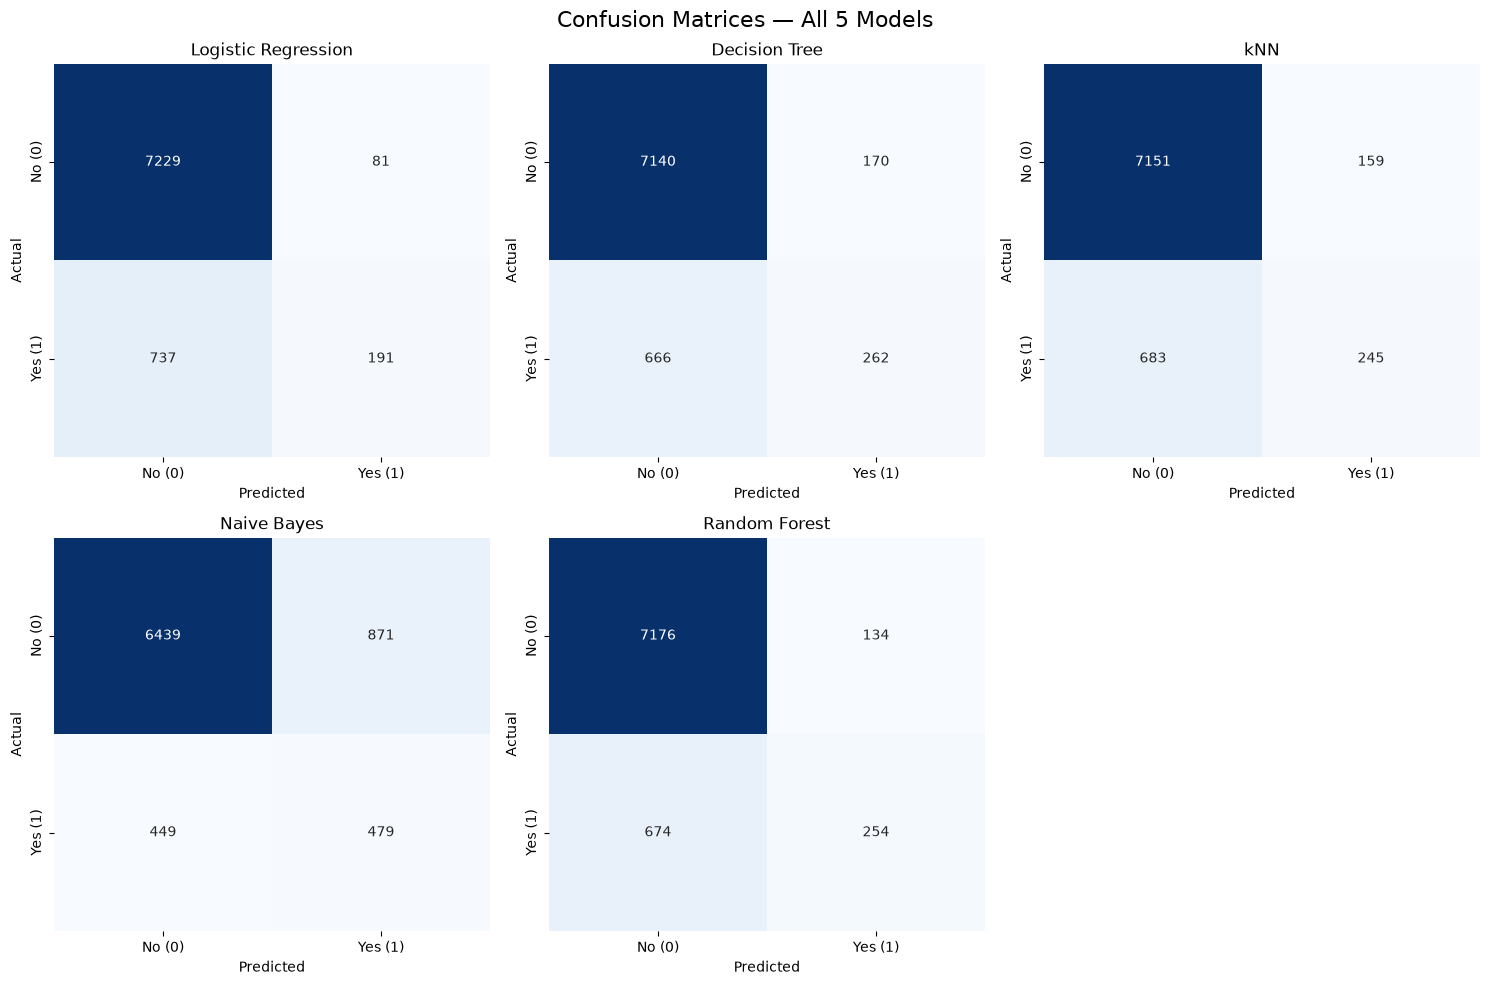


=== Logistic Regression ===
              precision    recall  f1-score   support

      No (0)       0.91      0.99      0.95      7310
     Yes (1)       0.70      0.21      0.32       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.63      8238
weighted avg       0.88      0.90      0.88      8238


=== Decision Tree ===
              precision    recall  f1-score   support

      No (0)       0.91      0.98      0.94      7310
     Yes (1)       0.61      0.28      0.39       928

    accuracy                           0.90      8238
   macro avg       0.76      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238




=== kNN ===
              precision    recall  f1-score   support

      No (0)       0.91      0.98      0.94      7310
     Yes (1)       0.61      0.26      0.37       928

    accuracy                           0.90      8238
   macro avg       0.76      0.62      0.66      8238
weighted avg       0.88      0.90      0.88      8238


=== Naive Bayes ===
              precision    recall  f1-score   support

      No (0)       0.93      0.88      0.91      7310
     Yes (1)       0.35      0.52      0.42       928

    accuracy                           0.84      8238
   macro avg       0.64      0.70      0.66      8238
weighted avg       0.87      0.84      0.85      8238


=== Random Forest ===
              precision    recall  f1-score   support

      No (0)       0.91      0.98      0.95      7310
     Yes (1)       0.65      0.27      0.39       928

    accuracy                           0.90      8238
   macro avg       0.78      0.63      0.67      8238
weighted avg     

In [11]:
MODEL_FILES = {
    "Logistic Regression": "logistic_regression",
    "Decision Tree": "decision_tree",
    "kNN": "knn",
    "Naive Bayes": "naive_bayes",
    "Random Forest": "random_forest",
}

X_test_arr = np.asarray(X_test_t, dtype=np.float64)
y_test_arr = y_test.values

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (label, key) in zip(axes, MODEL_FILES.items()):
    model = joblib.load(SAVED / f"{key}.pkl")
    y_pred = model.predict(X_test_arr)
    cm = confusion_matrix(y_test_arr, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No (0)", "Yes (1)"],
                yticklabels=["No (0)", "Yes (1)"], ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(label)

axes[-1].axis("off")
fig.suptitle("Confusion Matrices — All 5 Models", fontsize=16)
fig.tight_layout()
plt.show()

for label, key in MODEL_FILES.items():
    model = joblib.load(SAVED / f"{key}.pkl")
    y_pred = model.predict(X_test_arr)
    print(f"\n=== {label} ===")
    print(classification_report(y_test_arr, y_pred, target_names=["No (0)", "Yes (1)"]))